In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
from pathlib import Path

In [3]:
project_root = Path.cwd().parent
project_root

WindowsPath('C:/Users/chira/OneDrive/Desktop/customer-churn-predictor')

In [4]:
data_path = project_root / "data" / "processed" / "Telco-Churn_cleaned-1.csv"

In [5]:
df = pd.read_csv(data_path)

In [6]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [7]:
df.shape

(7043, 20)

In [8]:
df.head(4)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No


In [9]:
df.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [10]:
df.isna().sum().sum()

np.int64(0)

In [11]:
X = df.drop(columns=['Churn'])
y = df["Churn"]

In [12]:
print("X shape:",X.shape)
print("y shape:",y.shape)

X shape: (7043, 19)
y shape: (7043,)


#### Encode the target

In [13]:
y = y.replace({'Yes':1, 'No':0}).astype(int)
y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

#### Train/Test split

In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.22,
    random_state=42,
    stratify=y   # Our target is imbalanced (~73.5% vs ~26.5%), so we want both training and testing sets to maintain approximately the same class proportions.
    )

In [15]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Churn
0    0.734571
1    0.265429
Name: proportion, dtype: float64
Churn
0    0.734839
1    0.265161
Name: proportion, dtype: float64


#### Identify numerical and categorical features

In [16]:
numeric_features = x_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features = x_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### Build the preprocessing pipeline
#### Numerical -> scaling
#### Categorical -> one-hot encoding

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


numeric_pipeline = Pipeline([    
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [18]:
x_train_tf = preprocessor.fit_transform(x_train)
x_test_tf = preprocessor.transform(x_test)

In [19]:
x_train.shape

(5493, 19)

In [20]:
x_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
4462,Female,0,No,No,16,Yes,Yes,Fiber optic,No,No,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,88.45,1422.10
2861,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,81.95,81.95
3110,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.10,19.10
1498,Male,1,No,No,15,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,No,Electronic check,75.65,1146.65
1152,Male,0,No,No,7,Yes,No,DSL,No,No,No,No,Yes,No,Month-to-month,No,Mailed check,54.85,370.40


In [21]:
x_train_tf

array([[-0.4411914 , -0.66844431,  0.77845045, ...,  0.        ,
         1.        ,  0.        ],
       [-0.4411914 , -1.27806819,  0.56290745, ...,  0.        ,
         1.        ,  0.        ],
       [-0.4411914 , -1.27806819, -1.52122759, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-0.4411914 ,  0.2663123 ,  0.49824454, ...,  1.        ,
         0.        ,  0.        ],
       [-0.4411914 , -0.34331158, -1.47811899, ...,  1.        ,
         0.        ,  0.        ],
       [-0.4411914 , -1.07486023, -1.46982888, ...,  0.        ,
         0.        ,  1.        ]], shape=(5493, 45))

In [22]:
x_train_tf.shape

(5493, 45)

In [23]:
x_test_tf.shape

(1550, 45)

#### First baseline model

In [24]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000,random_state=42))
])

In [25]:
logistic_model.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [26]:
y_pred = logistic_model.predict(x_test)
y_prob = logistic_model.predict_proba(x_test)[:, 1]

In [27]:
y_pred

array([1, 0, 0, ..., 0, 0, 0], shape=(1550,))

In [28]:
y_pred.shape

(1550,)

#### Evaluate it properly

In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [30]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.8064516129032258
Precision: 0.6554621848739496
Recall   : 0.5693430656934306
F1 Score : 0.609375
ROC-AUC  : 0.847618925552572

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1139
           1       0.66      0.57      0.61       411

    accuracy                           0.81      1550
   macro avg       0.75      0.73      0.74      1550
weighted avg       0.80      0.81      0.80      1550



In [31]:
print("confusion matrix:")
print(confusion_matrix(y_test,y_pred))

confusion matrix:
[[1016  123]
 [ 177  234]]


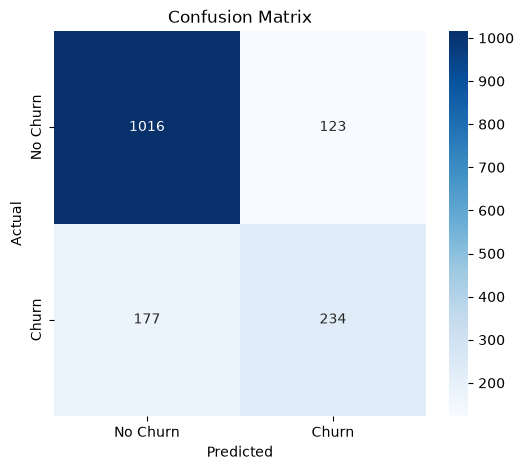

In [32]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [33]:
print(((1016+234)/(1016+234+177+123))*100)

80.64516129032258


#### second baseline model

In [34]:
from sklearn.tree import DecisionTreeClassifier
dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42,
        max_depth=5,
    ))
])

In [35]:
dt_model.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [36]:
model

NameError: name 'model' is not defined

In [53]:
y_pred1 = dt_model.predict(x_test)
y_prob1 = dt_model.predict_proba(x_test)[:,1]

In [54]:
print("Accuracy :", accuracy_score(y_test, y_pred1))
print("Precision:", precision_score(y_test, y_pred1))
print("Recall   :", recall_score(y_test, y_pred1))
print("F1 Score :", f1_score(y_test, y_pred1))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob1))

print("\nClassification Report:")
print(classification_report(y_test, y_pred1))

Accuracy : 0.7961290322580645
Precision: 0.6409495548961425
Recall   : 0.5255474452554745
F1 Score : 0.5775401069518716
ROC-AUC  : 0.8311982380924916

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1139
           1       0.64      0.53      0.58       411

    accuracy                           0.80      1550
   macro avg       0.74      0.71      0.72      1550
weighted avg       0.79      0.80      0.79      1550



In [55]:
print("confusion matrix:")
print(confusion_matrix(y_test,y_pred1))

confusion matrix:
[[1018  121]
 [ 195  216]]


Text(45.38563368055554, 0.5, 'Actual')

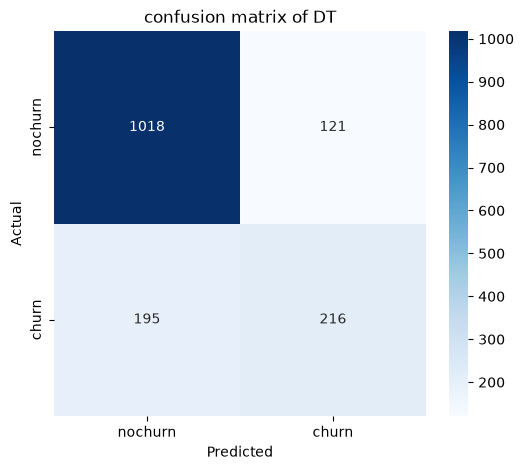

In [56]:
cm = confusion_matrix(y_test,y_pred1)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    fmt='d',
    cmap="Blues",
    annot=True,
    xticklabels=["nochurn","churn"],
    yticklabels=["nochurn","churn"]
)

plt.title("confusion matrix of DT")
plt.xlabel("Predicted")
plt.ylabel("Actual")

In [ ]:
from sklearn.tree import export_graphviz

print("digraph Tree:\n")
print(export_graphviz(dt_model))

#### third baseline model

In [58]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("prepocessor",preprocessor),
    ("model",RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        max_depth=None
    ))
])

In [59]:
rf_model.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prepocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pas

In [60]:
y_pred2 = rf_model.predict(x_test)
y_prob2 = rf_model.predict_proba(x_test)[:,1]

In [61]:
y_pred2

array([1, 0, 0, ..., 0, 0, 0], shape=(1550,))

In [62]:
y_pred2.shape

(1550,)

In [63]:
print("Accuracy :", accuracy_score(y_test, y_pred2))
print("Precision:", precision_score(y_test, y_pred2))
print("Recall   :", recall_score(y_test, y_pred2))
print("F1 Score :", f1_score(y_test, y_pred2))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob2))

print("\nClassification Report:")
print(classification_report(y_test, y_pred2))

Accuracy : 0.775483870967742
Precision: 0.5957446808510638
Recall   : 0.4768856447688564
F1 Score : 0.5297297297297298
ROC-AUC  : 0.8237056452388123

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1139
           1       0.60      0.48      0.53       411

    accuracy                           0.78      1550
   macro avg       0.71      0.68      0.69      1550
weighted avg       0.76      0.78      0.77      1550



Text(0.5, 1.0, 'confusion matrix of RF')

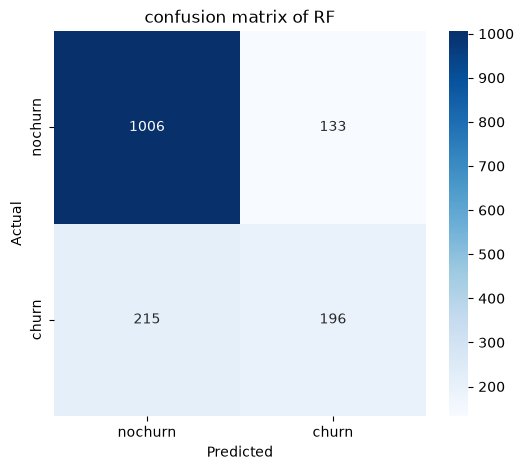

In [64]:
plt.figure(figsize=(6,5))
sns.heatmap(
    confusion_matrix(y_test,y_pred2),
    fmt='d',
    cmap="Blues",
    annot=True,
    xticklabels = ["nochurn","churn"],
    yticklabels = ["nochurn","churn"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("confusion matrix of RF")

In [65]:
baseline_result = {
    "model":"Log_Reg",
    "Accuracy" : accuracy_score(y_test, y_pred),
    "Precision" : precision_score(y_test, y_pred),
    "Recall" : recall_score(y_test, y_pred),
    "F1 Score" : f1_score(y_test, y_pred),
    "ROC-AUC" : roc_auc_score(y_test, y_prob)
}

dt_result = {
    "model":"dcision tree",
    "Accuracy" : accuracy_score(y_test, y_pred1),
    "Precision" : precision_score(y_test, y_pred1),
    "Recall" : recall_score(y_test, y_pred1),
    "F1 Score" : f1_score(y_test, y_pred1),
    "ROC-AUC" : roc_auc_score(y_test, y_prob1)
}

rf_result = {
    "model":"Random forest",
    "Accuracy" : accuracy_score(y_test, y_pred2),
    "Precision" : precision_score(y_test, y_pred2),
    "Recall" : recall_score(y_test, y_pred2),
    "F1 Score" : f1_score(y_test, y_pred2),
    "ROC-AUC" : roc_auc_score(y_test, y_prob2)
}

In [66]:
result = pd.DataFrame([
    baseline_result,
    dt_result,
    rf_result
    ]
)

In [67]:
result

,model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Log_Reg,0.806452,0.655462,0.569343,0.609375,0.847619
1,dcision tree,0.796129,0.640950,0.525547,0.577540,0.831198
2,Random forest,0.775484,0.595745,0.476886,0.529730,0.823706


#### gradient decent

In [68]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = Pipeline([
    ("preprocessor",preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

In [69]:
gb_model.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [70]:
pred_Gb = gb_model.predict(x_test)
pred_Gb_prob = gb_model.predict_proba(x_test)[:,1]

Text(0.5, 1.0, 'confusion matrix of GradientBoost')

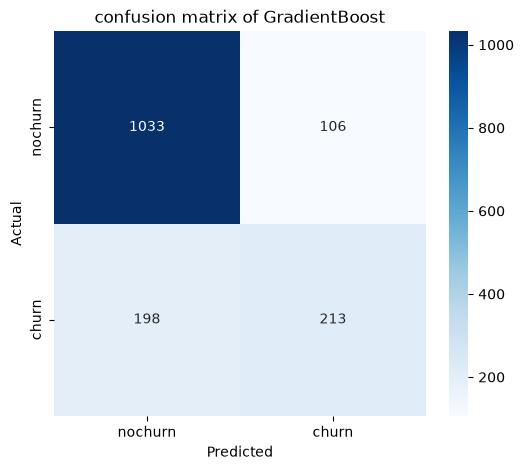

In [71]:
plt.figure(figsize=(6,5))
sns.heatmap(
    confusion_matrix(y_test,pred_Gb),
    fmt='d',
    cmap="Blues",
    annot=True,
    xticklabels = ["nochurn","churn"],
    yticklabels = ["nochurn","churn"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("confusion matrix of GradientBoost")

In [72]:
gb_result = {
    "model":"gradient boost",
    "Accuracy" : accuracy_score(y_test, pred_Gb),
    "Precision" : precision_score(y_test, pred_Gb),
    "Recall" : recall_score(y_test, pred_Gb),
    "F1 Score" : f1_score(y_test, pred_Gb),
    "ROC-AUC" : roc_auc_score(y_test, pred_Gb_prob)
}

In [73]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

ab_model = Pipeline([
    ("preprocessor",preprocessor),
    ("model", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ))
])

In [74]:
ab_model.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [75]:
pred_Ab = ab_model.predict(x_test)
pred_Ab_prob = ab_model.predict_proba(x_test)[:,1]

Text(0.5, 1.0, 'confusion matrix of AdaBoost')

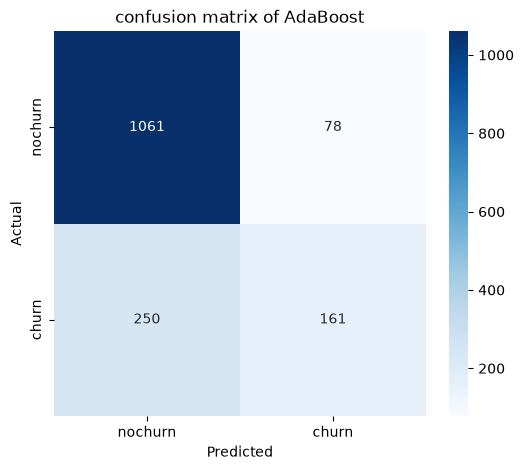

In [76]:
plt.figure(figsize=(6,5))
sns.heatmap(
    confusion_matrix(y_test,pred_Ab),
    fmt='d',
    cmap="Blues",
    annot=True,
    xticklabels = ["nochurn","churn"],
    yticklabels = ["nochurn","churn"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("confusion matrix of AdaBoost")

In [77]:
ab_result = {
    "model":"Ada boost",
    "Accuracy" : accuracy_score(y_test, pred_Ab),
    "Precision" : precision_score(y_test, pred_Ab),
    "Recall" : recall_score(y_test, pred_Ab),
    "F1 Score" : f1_score(y_test, pred_Ab),
    "ROC-AUC" : roc_auc_score(y_test, pred_Ab_prob)
}

In [78]:
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
        eval_metric="logloss"
    ))
])

In [79]:
xgb_model.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [80]:
pred_xgb = xgb_model.predict(x_test)
pred_xgb_prob = xgb_model.predict_proba(x_test)[:,1]

Text(0.5, 1.0, 'confusion matrix of XGBoost')

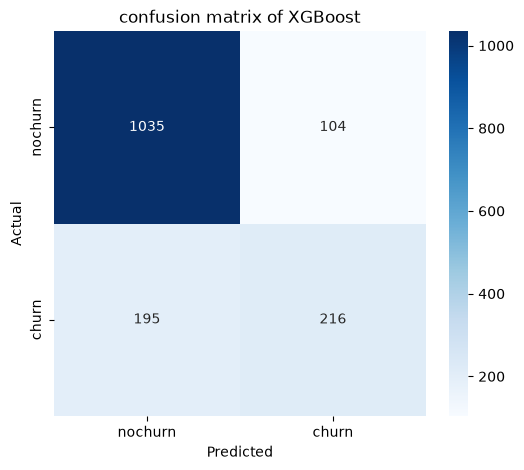

In [81]:
plt.figure(figsize=(6,5))
sns.heatmap(
    confusion_matrix(y_test,pred_xgb),
    fmt='d',
    cmap="Blues",
    annot=True,
    xticklabels = ["nochurn","churn"],
    yticklabels = ["nochurn","churn"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("confusion matrix of XGBoost")

In [82]:
xgb_result = {
    "model":"XGBoost",
    "Accuracy" : accuracy_score(y_test, pred_xgb),
    "Precision" : precision_score(y_test, pred_xgb),
    "Recall" : recall_score(y_test, pred_xgb),
    "F1 Score" : f1_score(y_test, pred_xgb),
    "ROC-AUC" : roc_auc_score(y_test, pred_xgb_prob)
}

In [83]:
compare_model = pd.DataFrame([
    gb_result,
    xgb_result,
    ab_result
])

In [84]:
compare_model

,model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,gradient boost,0.803871,0.667712,0.518248,0.583562,0.847186
1,XGBoost,0.807097,0.675000,0.525547,0.590971,0.848555
2,Ada boost,0.788387,0.673640,0.391727,0.495385,0.840869


#### Hyperparameter tuning

In [91]:
from scipy.stats import randint, uniform

param_dist = {
    "model__n_estimators": randint(100, 500),
    "model__max_depth": randint(2, 7),
    "model__learning_rate": uniform(0.01, 0.15),
    "model__min_child_weight": randint(1, 10),
    "model__subsample": uniform(0.7, 0.3),
    "model__colsample_bytree": uniform(0.7, 0.3),
    "model__gamma": uniform(0, 0.5)
}

In [109]:
# RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV

xgb_tuning = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc", # scoring roc_auc
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [110]:
xgb_tuning.fit(x_train,y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': <scipy.stats....001EDC618B790>, 'model__gamma': <scipy.stats....001EE281C4050>, 'model__learning_rate': <scipy.stats....001EE28268050>, 'model__max_depth': <scipy.stats....001EDC617BA80>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other 

In [95]:
print("Best ROC-AUC:", xgb_tuning.best_score_)
print("\nBest parameters:")
print(xgb_tuning.best_params_)

Best ROC-AUC: 0.848422654104412

Best parameters:
{'model__colsample_bytree': np.float64(0.9087353198035246), 'model__gamma': np.float64(0.11427501089864983), 'model__learning_rate': np.float64(0.03624323906439043), 'model__max_depth': 2, 'model__min_child_weight': 4, 'model__n_estimators': 159, 'model__subsample': np.float64(0.7782487524491226)}


In [97]:
from sklearn.model_selection import RandomizedSearchCV

xgb_tuning1 = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=30,
    scoring="accuracy", # accuracy
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [98]:
xgb_tuning1.fit(x_train,y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': <scipy.stats....001EDC618B790>, 'model__gamma': <scipy.stats....001EE281C4050>, 'model__learning_rate': <scipy.stats....001EE28268050>, 'model__max_depth': <scipy.stats....001EDC617BA80>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other

In [99]:
print("Best accuracy:", xgb_tuning1.best_score_)
print("\nBest parameters:")
print(xgb_tuning1.best_params_)

Best accuracy: 0.8050251014749291

Best parameters:
{'model__colsample_bytree': np.float64(0.9312901539863683), 'model__gamma': np.float64(0.24689779818219537), 'model__learning_rate': np.float64(0.0884099244072991), 'model__max_depth': 3, 'model__min_child_weight': 3, 'model__n_estimators': 162, 'model__subsample': np.float64(0.9687290787020557)}


In [111]:
best_xgb = xgb_tuning.best_estimator_

In [112]:
best_xgb

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

#### Evaluate tuned XGBoost

In [113]:
tuned_pred = best_xgb.predict(x_test)
tuned_prob = best_xgb.predict_proba(x_test)[:, 1]

In [114]:
tuned_results = {
    "model": "Tuned XGBoost",
    "Accuracy": accuracy_score(y_test, tuned_pred),
    "Precision": precision_score(y_test, tuned_pred),
    "Recall": recall_score(y_test, tuned_pred),
    "F1 Score": f1_score(y_test, tuned_pred),
    "ROC-AUC": roc_auc_score(y_test, tuned_prob)
}

tuned_results

{'model': 'Tuned XGBoost',
 'Accuracy': 0.8070967741935484,
 'Precision': 0.6761006289308176,
 'Recall': 0.5231143552311436,
 'F1 Score': 0.5898491083676269,
 'ROC-AUC': 0.8504440015465824}

In [115]:
results = pd.DataFrame([
    baseline_result,
    dt_result,
    rf_result,
    gb_result,
    ab_result,
    xgb_result,
    tuned_results
])

results.sort_values("ROC-AUC", ascending=False)

,model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
6,Tuned XGBoost,0.807097,0.676101,0.523114,0.589849,0.850444
5,XGBoost,0.807097,0.675000,0.525547,0.590971,0.848555
0,Log_Reg,0.806452,0.655462,0.569343,0.609375,0.847619
3,gradient boost,0.803871,0.667712,0.518248,0.583562,0.847186
4,Ada boost,0.788387,0.673640,0.391727,0.495385,0.840869
1,dcision tree,0.796129,0.640950,0.525547,0.577540,0.831198
2,Random forest,0.775484,0.595745,0.476886,0.529730,0.823706


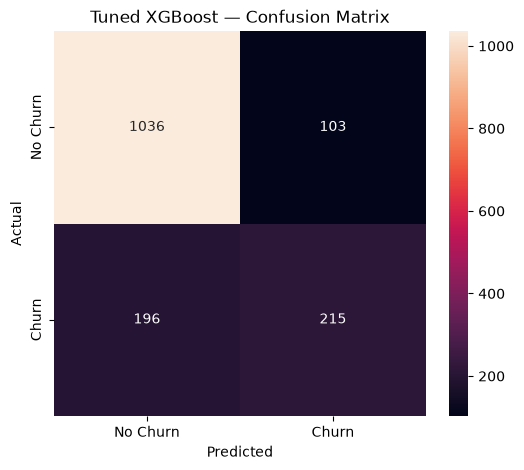

In [116]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, tuned_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned XGBoost — Confusion Matrix")
plt.show()

In [117]:
comparison = pd.DataFrame([
    xgb_result,
    tuned_results
])

comparison

,model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.807097,0.675000,0.525547,0.590971,0.848555
1,Tuned XGBoost,0.807097,0.676101,0.523114,0.589849,0.850444


In [118]:
tuned_prob

array([0.39315987, 0.04179624, 0.22941703, ..., 0.03615895, 0.35065797,
       0.10640111], shape=(1550,), dtype=float32)

In [119]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.20, 0.71, 0.05)

threshold_results = []

for threshold in thresholds:
    predictions = (tuned_prob >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, predictions),
        "recall": recall_score(y_test, predictions),
        "f1": f1_score(y_test, predictions)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,threshold,precision,recall,f1
0,0.20,0.482240,0.858881,0.617673
1,0.25,0.521605,0.822384,0.638338
2,0.30,0.540816,0.773723,0.636637
3,0.35,0.575397,0.705596,0.633880
4,0.40,0.596330,0.632603,0.613932
5,0.45,0.624672,0.579075,0.601010
6,0.50,0.676101,0.523114,0.589849
7,0.55,0.717131,0.437956,0.543807
8,0.60,0.743590,0.352798,0.478548
9,0.65,0.763889,0.267640,0.396396


In [120]:
np.arange(0.20, 0.71, 0.05)

array([0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55, 0.6 , 0.65, 0.7 ])

In [121]:
best_threshold_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

best_threshold_row

threshold    0.250000
precision    0.521605
recall       0.822384
f1           0.638338
Name: 1, dtype: float64

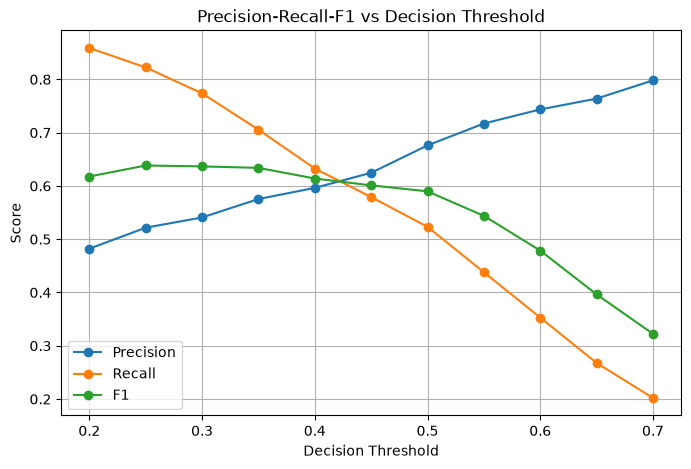

In [122]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    marker="o",
    label="F1"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall-F1 vs Decision Threshold")
plt.legend()
plt.grid(True)
plt.show()

#### Create the final prediction function

In [123]:
FINAL_THRESHOLD = 0.25
final_pred = (tuned_prob >= FINAL_THRESHOLD).astype(int)

In [125]:
final_pred

array([1, 0, 0, ..., 0, 1, 0], shape=(1550,))

In [126]:
final_precision = precision_score(y_test, final_pred)
final_recall = recall_score(y_test, final_pred)
final_f1 = f1_score(y_test, final_pred)
final_accu = accuracy_score(y_test, final_pred)

print("Final Threshold:", FINAL_THRESHOLD)
print("Precision:", final_precision)
print("Recall:", final_recall)
print("F1 Score:", final_f1)
print("accuracy score:", final_accu)
print("ROC-AUC:", roc_auc_score(y_test, tuned_prob))

Final Threshold: 0.25
Precision: 0.5216049382716049
Recall: 0.8223844282238443
F1 Score: 0.6383380547686497
accuracy score: 0.7529032258064516
ROC-AUC: 0.8504440015465824


#### Final confusion matrix

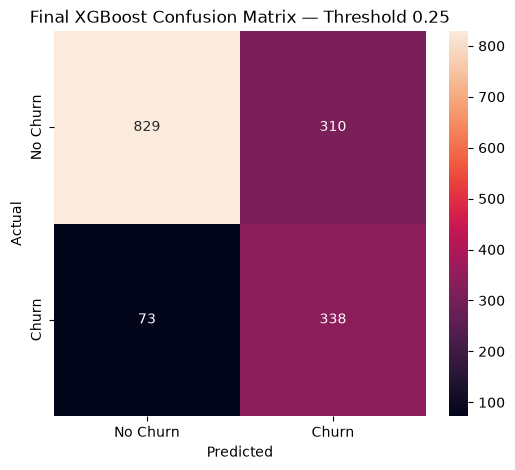

In [127]:
final_cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final XGBoost Confusion Matrix — Threshold 0.25")
plt.show()

#### Create a validation set

In [128]:
x_train.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
4462,Female,0,No,No,16,Yes,Yes,Fiber optic,No,No,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,88.45,1422.10
2861,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,81.95,81.95


In [129]:
x_test.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
2086,Male,0,Yes,Yes,17,Yes,No,Fiber optic,No,No,No,No,Yes,No,Month-to-month,No,Electronic check,80.85,1400.85
3036,Male,0,No,No,67,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,One year,Yes,Bank transfer (automatic),49.35,3321.35


In [130]:
y_train.head(3)

4462    1
2861    1
3110    0
Name: Churn, dtype: int64

In [131]:
y_test.head(3)

2086    1
3036    0
4792    1
Name: Churn, dtype: int64

In [132]:
x_train_sub, x_val, y_train_sub, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training:",x_train_sub.shape)
print("Validation:",x_val.shape)

Training: (4394, 19)
Validation: (1099, 19)


#### Create the final XGBoost pipeline

In [133]:
from xgboost import XGBClassifier
from sklearn.base import clone

final_xgb = clone(best_xgb)

In [134]:
final_xgb.fit(x_train_sub,y_train_sub)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

#### Get validation probablities

In [135]:
val_prob = final_xgb.predict_proba(x_val)[:,1]

In [136]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.20, 0.71, 0.01)

validation_results = []

for threshold in thresholds:

    val_pred = (val_prob >= threshold).astype(int)

    validation_results.append({
        "threshold": threshold,
        "precision": precision_score(y_val, val_pred),
        "recall": recall_score(y_val, val_pred),
        "f1": f1_score(y_val, val_pred)
    })

validation_df = pd.DataFrame(validation_results)

validation_df

,threshold,precision,recall,f1
0,0.20,0.472998,0.869863,0.612786
1,0.21,0.480916,0.863014,0.617647
2,0.22,0.481336,0.839041,0.611735
3,0.23,0.482000,0.825342,0.608586
4,0.24,0.482759,0.815068,0.606369
5,0.25,0.491701,0.811644,0.612403
6,0.26,0.497881,0.804795,0.615183
7,0.27,0.505423,0.797945,0.618858
8,0.28,0.514541,0.787671,0.622463
9,0.29,0.524138,0.780822,0.627235


In [137]:
best_threshold_row = validation_df.loc[
    validation_df["f1"].idxmax()
]
best_threshold_row

threshold    0.450000
precision    0.644366
recall       0.626712
f1           0.635417
Name: 25, dtype: float64

In [138]:
validation_df[
    validation_df["recall"] >= 0.80
].sort_values(
    "precision",
    ascending=False
).head(10)

,threshold,precision,recall,f1
6,0.26,0.497881,0.804795,0.615183
5,0.25,0.491701,0.811644,0.612403
4,0.24,0.482759,0.815068,0.606369
3,0.23,0.482000,0.825342,0.608586
2,0.22,0.481336,0.839041,0.611735
1,0.21,0.480916,0.863014,0.617647
0,0.20,0.472998,0.869863,0.612786


In [139]:
eligible_thresholds = validation_df[
    validation_df["recall"]>=0.80
]
selected_threshold_row = eligible_thresholds.loc[
    eligible_thresholds["precision"].idxmax()
]
selected_threshold = selected_threshold_row["threshold"]
print("selected threshold:", selected_threshold)
print(selected_threshold_row)

selected threshold: 0.26000000000000006
threshold    0.260000
precision    0.497881
recall       0.804795
f1           0.615183
Name: 6, dtype: float64


#### Train the final model on All training data

In [140]:
final_xgb.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [141]:
test_prob = final_xgb.predict_proba(x_test)[:, 1]

final_test_pred = (
    test_prob >= selected_threshold
).astype(int)

In [142]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Final Test Results")
print("------------------")
print("Threshold :", selected_threshold)
print("Accuracy  :", accuracy_score(y_test, final_test_pred))
print("Precision :", precision_score(y_test, final_test_pred))
print("Recall    :", recall_score(y_test, final_test_pred))
print("F1 Score  :", f1_score(y_test, final_test_pred))
print("ROC-AUC   :", roc_auc_score(y_test, test_prob))

Final Test Results
------------------
Threshold : 0.26000000000000006
Accuracy  : 0.7554838709677419
Precision : 0.525
Recall    : 0.8175182481751825
F1 Score  : 0.6393910561370124
ROC-AUC   : 0.8504440015465824


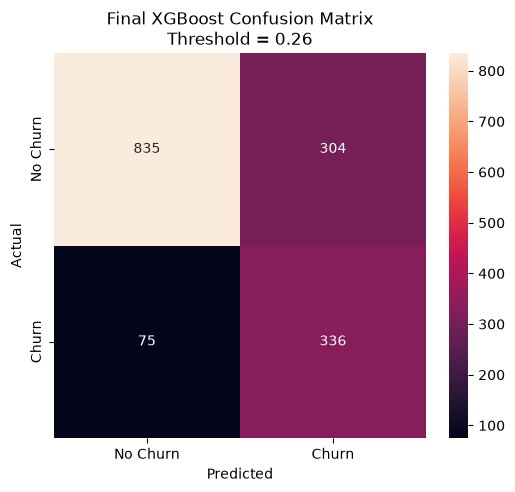

In [143]:
final_cm = confusion_matrix(y_test, final_test_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(
    f"Final XGBoost Confusion Matrix\nThreshold = {selected_threshold:.2f}"
)

plt.show()

In [144]:
preprocessor_final = final_xgb.named_steps["preprocessor"]
xgb_final = final_xgb.named_steps["model"]

In [145]:
print(type(preprocessor_final))
print(type(xgb_final))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>
<class 'xgboost.sklearn.XGBClassifier'>


In [146]:
# 2. Transform test data
x_test_transformed = preprocessor_final.transform(x_test)
print(x_test_transformed.shape)

(1550, 45)


In [147]:
feature_names = preprocessor_final.get_feature_names_out()

print("Number of features:", len(feature_names))
print(feature_names[:20])

Number of features: 45
['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'cat__gender_Female' 'cat__gender_Male'
 'cat__Partner_No' 'cat__Partner_Yes' 'cat__Dependents_No'
 'cat__Dependents_Yes' 'cat__PhoneService_No' 'cat__PhoneService_Yes'
 'cat__MultipleLines_No' 'cat__MultipleLines_No phone service'
 'cat__MultipleLines_Yes' 'cat__InternetService_DSL'
 'cat__InternetService_Fiber optic' 'cat__InternetService_No'
 'cat__OnlineSecurity_No' 'cat__OnlineSecurity_No internet service']


#### Create the SHAP explainer

In [148]:
import shap

In [149]:
explainer = shap.TreeExplainer(xgb_final)

In [150]:
x_shap = x_test_transformed[:1000]
shap_values = explainer(x_shap)

In [151]:
print(shap_values.shape)

(1000, 45)


#### Global feature importance

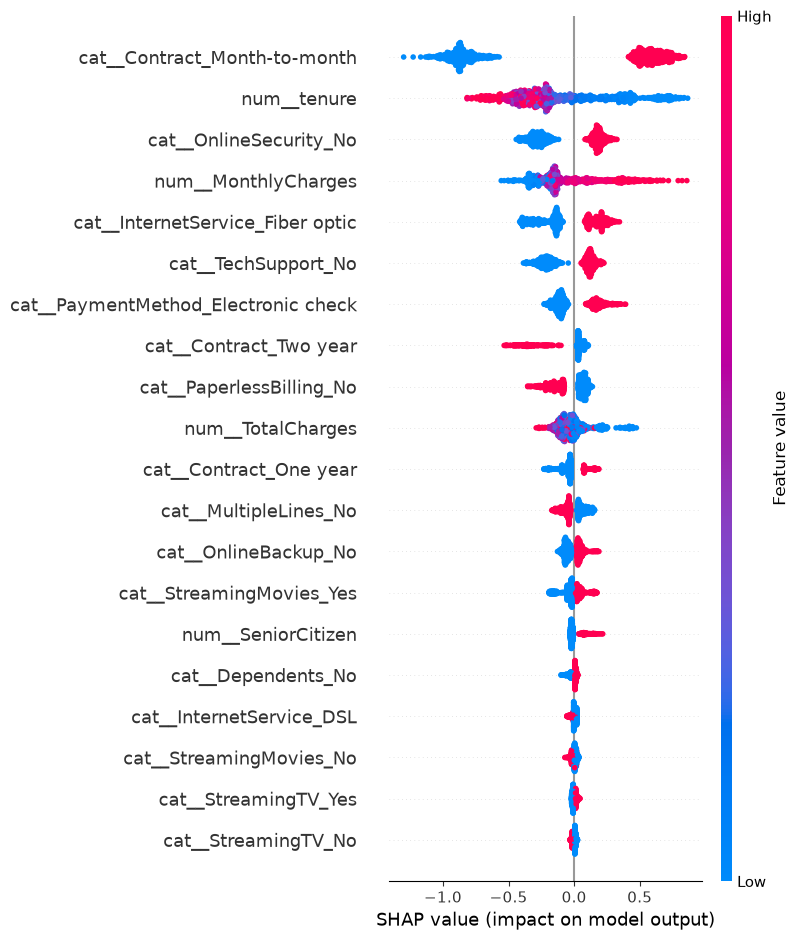

In [152]:
shap.summary_plot(
    shap_values,
    x_shap,
    feature_names=feature_names
)

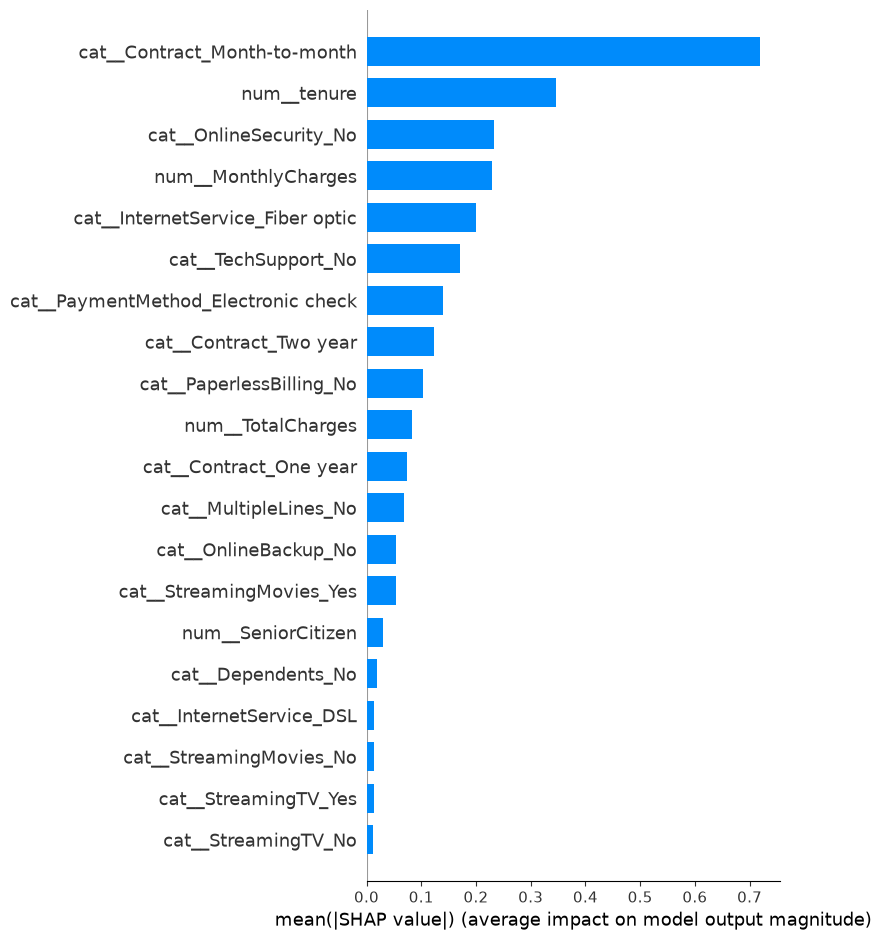

In [153]:
shap.summary_plot(
    shap_values,
    x_shap,
    feature_names=feature_names,
    plot_type="bar"
)

In [154]:
customer_index = 0

In [155]:
import numpy as np
import pandas as pd

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap
})

shap_importance = shap_importance.sort_values(
    "mean_abs_shap",
    ascending=False
)

shap_importance.head(15)

,feature,mean_abs_shap
36,cat__Contract_Month-to-month,0.719485
1,num__tenure,0.346554
18,cat__OnlineSecurity_No,0.233136
2,num__MonthlyCharges,0.229893
16,cat__InternetService_Fiber optic,0.199134
27,cat__TechSupport_No,0.170307
43,cat__PaymentMethod_Electronic check,0.139818
38,cat__Contract_Two year,0.122380
39,cat__PaperlessBilling_No,0.103594
3,num__TotalCharges,0.082806


In [156]:
customer_shap = shap_values[customer_index]

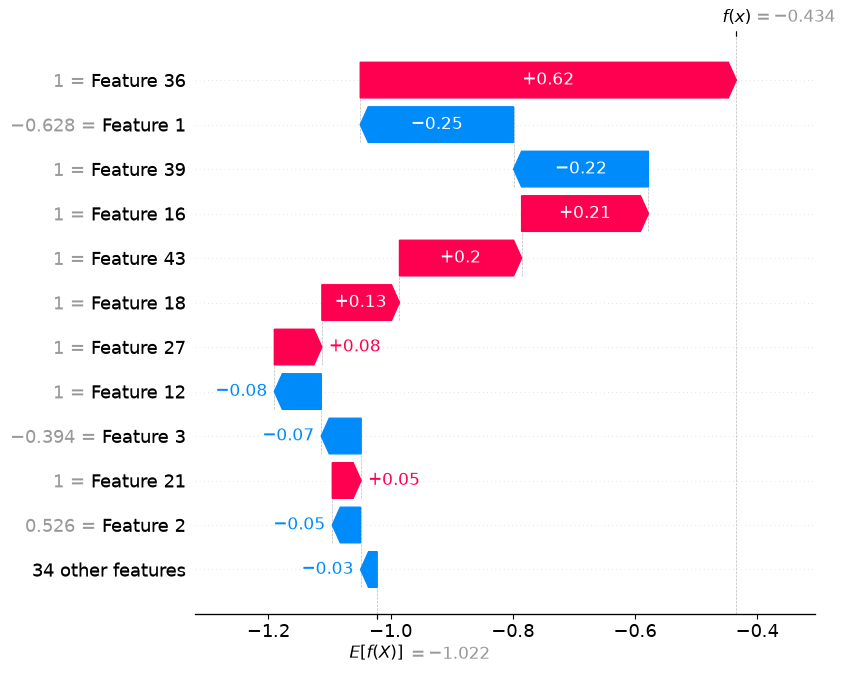

In [157]:
shap.plots.waterfall(customer_shap, max_display=12)

In [158]:
x_test.iloc[customer_index]

gender                          Male
SeniorCitizen                      0
Partner                          Yes
Dependents                       Yes
tenure                            17
PhoneService                     Yes
MultipleLines                     No
InternetService          Fiber optic
OnlineSecurity                    No
OnlineBackup                      No
DeviceProtection                  No
TechSupport                       No
StreamingTV                      Yes
StreamingMovies                   No
Contract              Month-to-month
PaperlessBilling                  No
PaymentMethod       Electronic check
MonthlyCharges                 80.85
TotalCharges                 1400.85
Name: 2086, dtype: object

In [159]:
print("Actual:", y_test.iloc[customer_index])
print("Predicted:", final_test_pred[customer_index])
print("Probability:", test_prob[customer_index])

Actual: 1
Predicted: 1
Probability: 0.39315987


In [163]:
import joblib
modelpath =  project_root / "models" / "churn_model.pkl"
joblib.dump(final_xgb, modelpath)

['C:\\Users\\chira\\OneDrive\\Desktop\\customer-churn-predictor\\models\\churn_model.pkl']

In [164]:
FINAL_THRESHOLD = float(selected_threshold)

joblib.dump(
    FINAL_THRESHOLD,
    project_root/"models"/"threshold.pkl"
)

print("Threshold saved:", FINAL_THRESHOLD)

Threshold saved: 0.26000000000000006


In [168]:
loaded_model = joblib.load(project_root/"models"/"churn_model.pkl")

loaded_threshold = joblib.load(project_root/"models"/"threshold.pkl")

In [170]:
loaded_prob = loaded_model.predict_proba(x_test)[:, 1]

loaded_pred = (
    loaded_prob >= loaded_threshold
).astype(int)

In [171]:
print(
    "Predictions identical:",
    np.array_equal(final_test_pred, loaded_pred)
)

Predictions identical: True


In [172]:
model_info = {
    "model": "XGBoost",
    "threshold": FINAL_THRESHOLD,
    "roc_auc": roc_auc_score(y_test, test_prob),
    "accuracy": accuracy_score(y_test, final_test_pred),
    "precision": precision_score(y_test, final_test_pred),
    "recall": recall_score(y_test, final_test_pred),
    "f1_score": f1_score(y_test, final_test_pred)
}

model_info

{'model': 'XGBoost',
 'threshold': 0.26000000000000006,
 'roc_auc': 0.8504440015465824,
 'accuracy': 0.7554838709677419,
 'precision': 0.525,
 'recall': 0.8175182481751825,
 'f1_score': 0.6393910561370124}

In [174]:
joblib.dump(model_info, project_root/"models"/"model_info.pkl")

['C:\\Users\\chira\\OneDrive\\Desktop\\customer-churn-predictor\\models\\model_info.pkl']

In [ ]:
best_xgb

In [ ]:
import joblib

joblib.dump(best_xgb, project_root / "models" / "best_xgb_model1.pkl")

In [ ]:
import numpy as np

In [ ]:
import joblib
from pathlib import Path
project_root = Path.cwd().parent

In [ ]:
model = joblib.load(project_root / "models" / "best_xgb_model1.pkl")

In [ ]:
sample = np.array(["Female",0,"Yes","No",17,"Yes","No","Fiber optic","No","No","No","No","Yes","No","Month-to-month","No","Bank transfer (automatic)",96.85,1600.85]).reshape(1,19)

In [ ]:
sample.shape

In [ ]:
import pandas as pd
sample_df = pd.DataFrame(sample)

In [ ]:
y_pred = model.predict(sample_df)

In [ ]:
y_pred

In [ ]:
x_test.shape[1]

In [ ]:
x_test

In [ ]:
x_test.info()